# import Libs

In [150]:
# Import Essential Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine, load_iris, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [151]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [152]:

print(" Stroke Prediction Dataset (Binary Classification)")
print(f"Shape: {df.shape}")
print(f"Features: {len(df.columns) - 1}")
print(f"Classes: ['No Stroke', 'Stroke']")
print(f"\nTarget Distribution:")
print(df['stroke'].value_counts())
print(f"\nClass Balance: {(df['stroke'].value_counts(normalize=True) * 100).round(2).to_dict()}")
print("\n" + "="*70)
print("First 5 rows:")
print(df.head())

 Stroke Prediction Dataset (Binary Classification)
Shape: (5110, 12)
Features: 11
Classes: ['No Stroke', 'Stroke']

Target Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Class Balance: {0: 95.13, 1: 4.87}

First 5 rows:
      id  gender   age  ...   bmi   smoking_status stroke
0   9046    Male  67.0  ...  36.6  formerly smoked      1
1  51676  Female  61.0  ...   NaN     never smoked      1
2  31112    Male  80.0  ...  32.5     never smoked      1
3  60182  Female  49.0  ...  34.4           smokes      1
4   1665  Female  79.0  ...  24.0     never smoked      1

[5 rows x 12 columns]


In [153]:
df.isnull().sum().sort_values(ascending=False)

bmi                  201
id                     0
age                    0
gender                 0
hypertension           0
heart_disease          0
work_type              0
ever_married           0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

In [154]:

num_cols = ['age', 'avg_glucose_level', 'bmi']

print("\n=== Outliers Detection using Z-score (threshold = 3) ===")

outlier_indices = set()

for col in num_cols:
    mean = df[col].mean()
    std = df[col].std()
    
    z_scores = np.abs((df[col] - mean) / std)
    
    outliers_mask = z_scores > 3
    outlier_count = outliers_mask.sum()
    
    print(f"\n{col.upper()}:")
    print(f"  → Number of outliers (Z > 3): {outlier_count}")
    print(f"  → Percentage: {outlier_count / len(df) * 100:.2f}%")
    print(f"  → Max Z-score: {z_scores.max():.2f}")
    
    outlier_indices.update(df[outliers_mask].index.tolist())

total_outliers = len(outlier_indices)
print(f"\nTotal unique rows with outliers (any column): {total_outliers}")
print(f"Percentage of data to be removed: {total_outliers / len(df) * 100:.2f}%")

print("\nBMI stats before removal:")
print(df['bmi'].describe())

df_clean = df.drop(index=list(outlier_indices)).reset_index(drop=True)

print("\nShape after removing outliers:", df_clean.shape)

print("\nBMI stats after removal:")
print(df_clean['bmi'].describe())


=== Outliers Detection using Z-score (threshold = 3) ===

AGE:
  → Number of outliers (Z > 3): 0
  → Percentage: 0.00%
  → Max Z-score: 1.91

AVG_GLUCOSE_LEVEL:
  → Number of outliers (Z > 3): 49
  → Percentage: 0.96%
  → Max Z-score: 3.66

BMI:
  → Number of outliers (Z > 3): 58
  → Percentage: 1.14%
  → Max Z-score: 8.75

Total unique rows with outliers (any column): 107
Percentage of data to be removed: 2.09%

BMI stats before removal:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

Shape after removing outliers: (5003, 12)

BMI stats after removal:
count    4805.000000
mean       28.511675
std         7.147473
min        10.300000
25%        23.500000
50%        27.900000
75%        32.800000
max        52.300000
Name: bmi, dtype: float64


In [155]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Class Distribution', 'Class Balance'),
                    specs=[[{"type": "bar"}, {"type": "pie"}]])

# Bar chart
counts = df['stroke'].value_counts()
fig.add_trace(
    go.Bar(x=['No Stroke (0)', 'Stroke (1)'],
           y=counts.values,
           marker_color=['lightblue', 'salmon'],
           text=counts.values,
           textposition='auto'),
    row=1, col=1
)

# Pie chart
fig.add_trace(
    go.Pie(labels=['No Stroke', 'Stroke'],
           values=counts.values,
           marker_colors=['lightblue', 'salmon'],
           textinfo='label+percent',
           hole=0.3),
    row=1, col=2
)

fig.update_layout(
    title_text='Stroke Dataset - Target Distribution & Balance',
    height=500,
    width=1000,
    showlegend=False
)

fig.update_xaxes(title_text="Class", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)

fig.show()

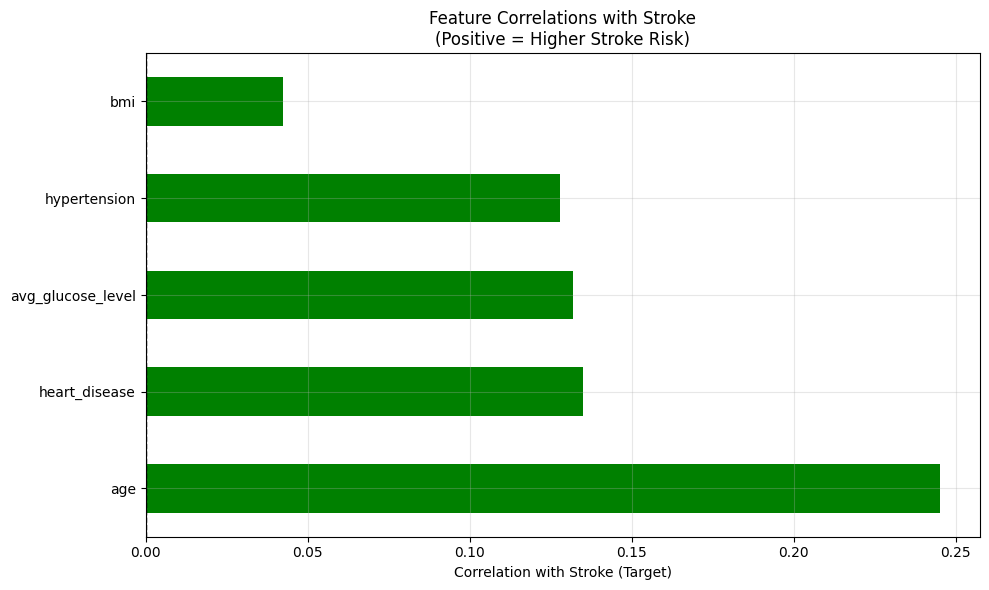


 Top Correlated Features with Stroke:
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.042374


In [156]:
relevant_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

correlations = df[relevant_cols].corr()['stroke'].drop('stroke').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlations])
plt.xlabel('Correlation with Stroke (Target)')
plt.title('Feature Correlations with Stroke\n(Positive = Higher Stroke Risk)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Top Correlated Features with Stroke:")
print(correlations.to_string())

# Machine Learning

In [157]:
# Copy clean dataframe
df = df.copy()

# Fill missing BMI with median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# One-hot encoding categorical features
categorical_cols = [
    'gender', 'ever_married', 'work_type',
    'Residence_type', 'smoking_status'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [158]:
X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (4088, 17)
Test shape: (1022, 17)


In [159]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])
model.fit(X_train, y_train)



,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [160]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [161]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy : 0.7485322896281801
Precision: 0.13937282229965156
Recall   : 0.8
F1-score : 0.23738872403560832

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



In [162]:
threshold = 0.3
y_pred_custom = (y_prob >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall   :", recall_score(y_test, y_pred_custom))
print("F1-score :", f1_score(y_test, y_pred_custom))


Precision: 0.0963302752293578
Recall   : 0.84
F1-score : 0.1728395061728395


In [163]:
lr = model.named_steps['lr']

weights = lr.coef_[0]
bias = lr.intercept_[0]

print("Intercept (b):", bias)


Intercept (b): -1.1693926548022247


In [164]:
feature_names = X.columns

sigmoid_eq = pd.Series(weights, index=feature_names).sort_values()

print("\nSigmoid function:")
print("P(stroke=1) = 1 / (1 + exp(-z))")
print("\nwhere:")
print("z = ", end="")

for f, w in sigmoid_eq.items():
    print(f"({w:.3f} * {f}) + ", end="")

print(f"{bias:.3f}")



Sigmoid function:
P(stroke=1) = 1 / (1 + exp(-z))

where:
z = (-0.102 * work_type_Never_worked) + (-0.079 * smoking_status_never smoked) + (-0.079 * ever_married_Yes) + (-0.077 * work_type_Self-employed) + (-0.064 * gender_Male) + (-0.046 * gender_Other) + (0.015 * work_type_Private) + (0.051 * bmi) + (0.053 * heart_disease) + (0.057 * smoking_status_formerly smoked) + (0.077 * Residence_type_Urban) + (0.115 * id) + (0.123 * smoking_status_smokes) + (0.177 * hypertension) + (0.197 * avg_glucose_level) + (0.358 * work_type_children) + (1.896 * age) + -1.169


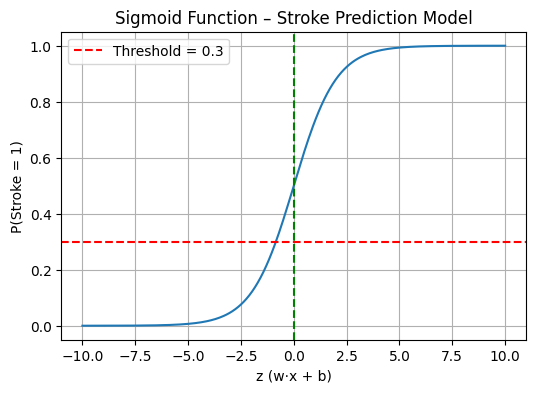

In [165]:
z_vals = np.linspace(-10, 10, 300)
sigmoid_vals = 1 / (1 + np.exp(-z_vals))

plt.figure(figsize=(6,4))
plt.plot(z_vals, sigmoid_vals)
plt.axhline(0.3, color='red', linestyle='--', label='Threshold = 0.3')
plt.axvline(0, color='green', linestyle='--')
plt.xlabel('z (w·x + b)')
plt.ylabel('P(Stroke = 1)')
plt.title('Sigmoid Function – Stroke Prediction Model')
plt.legend()
plt.grid()
plt.show()


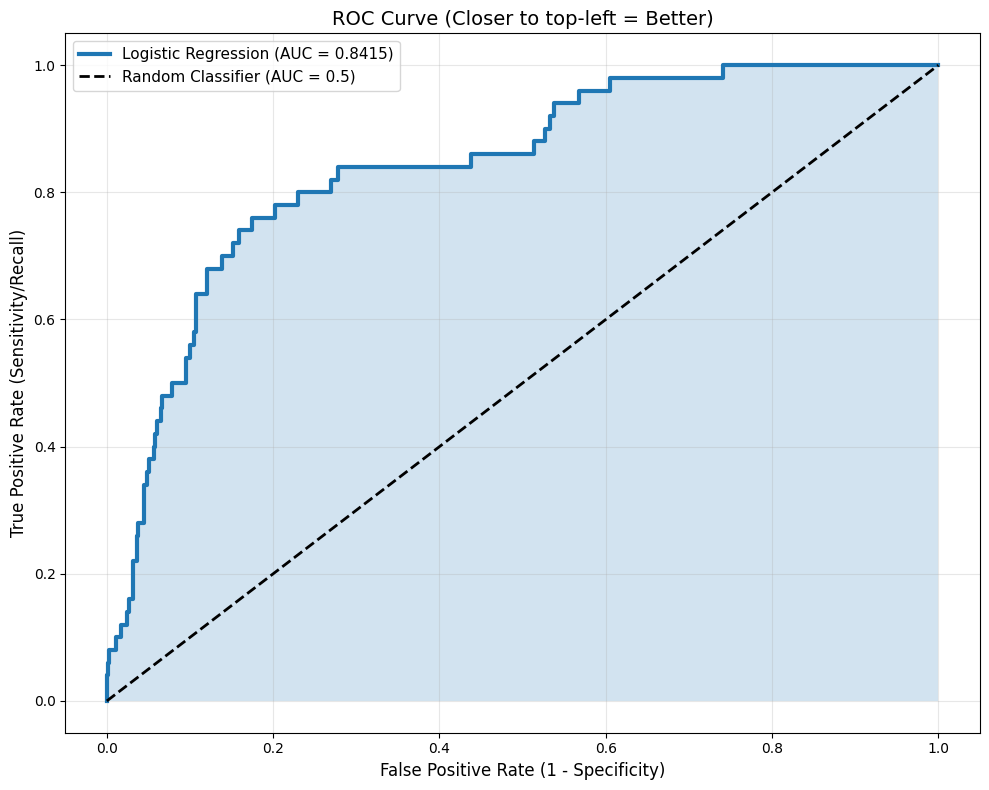

ROC-AUC Score: 0.8415
AUC Interpretation:
1.0 : Perfect classifier
0.9-1.0 : Excellent
0.8-0.9 : Good
0.7-0.8 : Fair
0.5-0.7 : Poor
0.5 : Random guessing


In [166]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=3, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.2)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
plt.title('ROC Curve (Closer to top-left = Better)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

print("AUC Interpretation:")
print("1.0 : Perfect classifier")
print("0.9-1.0 : Excellent")
print("0.8-0.9 : Good")
print("0.7-0.8 : Fair")
print("0.5-0.7 : Poor")
print("0.5 : Random guessing")

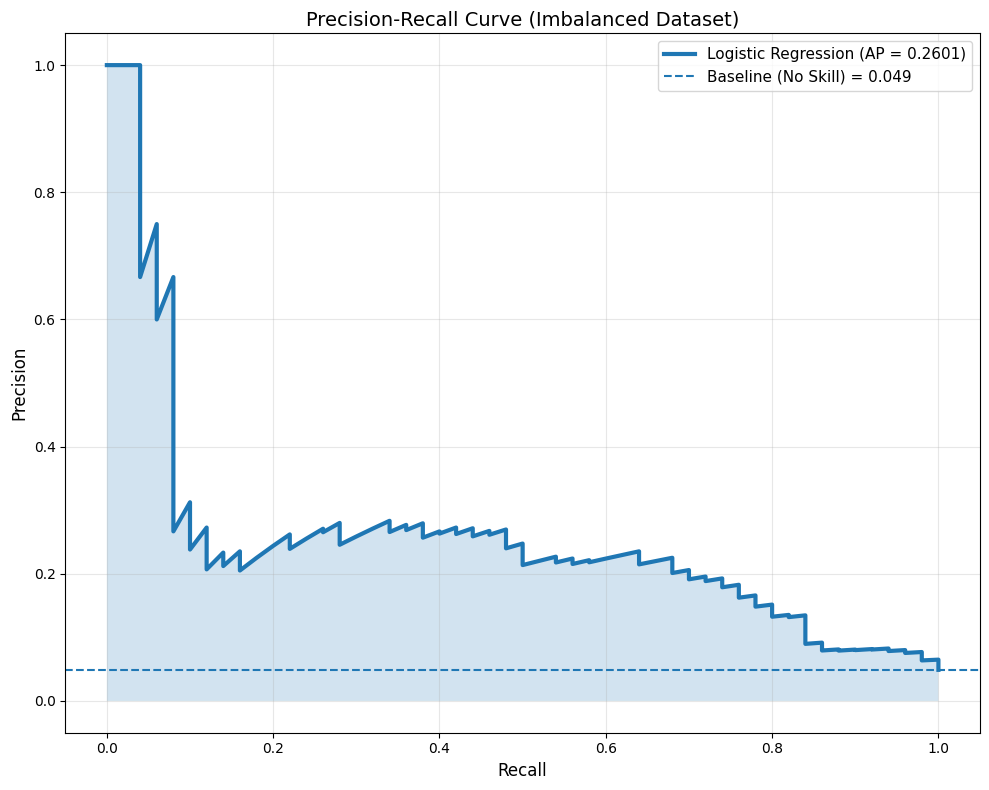

Average Precision Score: 0.2601


In [167]:
precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_test, y_prob
)

avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(10, 8))
plt.plot(
    recall_vals,
    precision_vals,
    linewidth=3,
    label=f'Logistic Regression (AP = {avg_precision:.4f})'
)

baseline = y_test.mean()
plt.axhline(
    y=baseline,
    linestyle='--',
    label=f'Baseline (No Skill) = {baseline:.3f}'
)

plt.fill_between(recall_vals, precision_vals, alpha=0.2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve (Imbalanced Dataset)', fontsize=14)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision Score: {avg_precision:.4f}")


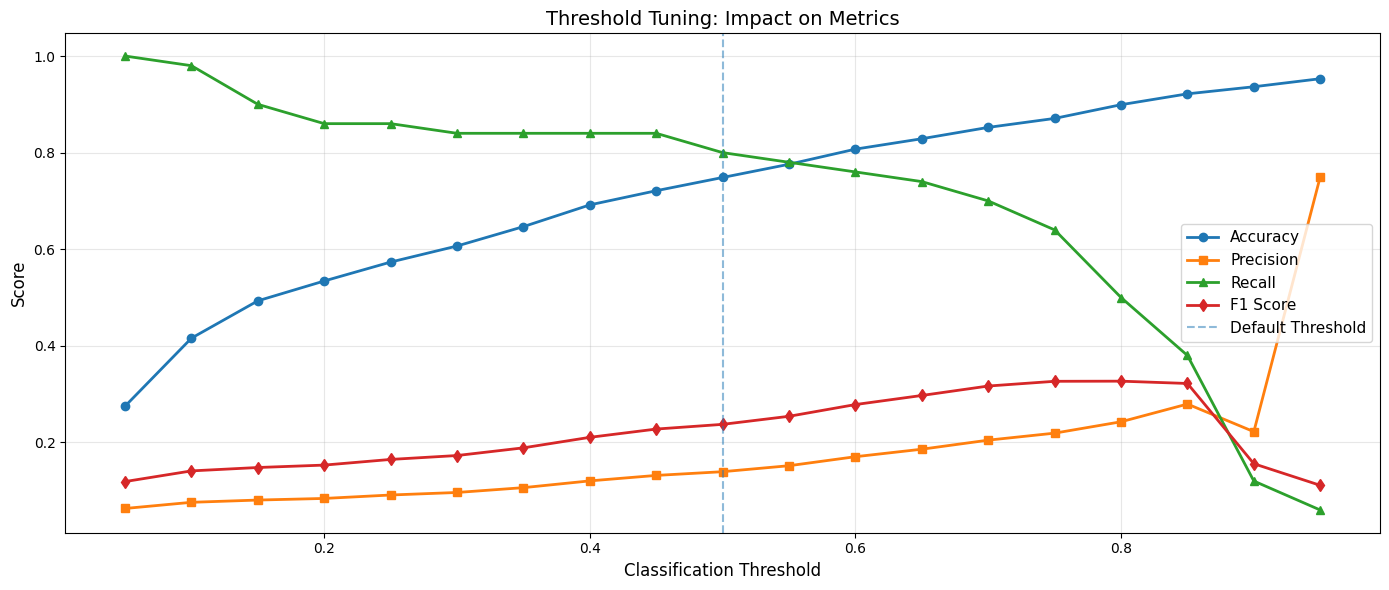

In [168]:
thresholds = np.linspace(0.05, 0.95, 19)

records = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    records.append({
        'Threshold': t,
        'Accuracy': accuracy_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(records)

plt.figure(figsize=(14, 6))

plt.plot(threshold_df['Threshold'], threshold_df['Accuracy'],
         marker='o', linewidth=2, label='Accuracy')
plt.plot(threshold_df['Threshold'], threshold_df['Precision'],
         marker='s', linewidth=2, label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'],
         marker='^', linewidth=2, label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1'],
         marker='d', linewidth=2, label='F1 Score')

plt.axvline(x=0.5, linestyle='--', alpha=0.5, label='Default Threshold')
plt.xlabel('Classification Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Threshold Tuning: Impact on Metrics', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [169]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
X = df.drop('stroke', axis=1)
y = pd.cut(df['avg_glucose_level'], bins=[0,100,150,300], labels=[0,1,2])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_ovr = LogisticRegression(multi_class='ovr', random_state=42, max_iter=10000)
log_reg_ovr.fit(X_train_scaled, y_train)
y_pred_ovr = log_reg_ovr.predict(X_test_scaled)
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)

log_reg_multi = LogisticRegression(multi_class='multinomial', random_state=42, max_iter=10000)
log_reg_multi.fit(X_train_scaled, y_train)
y_pred_multi = log_reg_multi.predict(X_test_scaled)
accuracy_multi = accuracy_score(y_test, y_pred_multi)

print("Multi-Class Logistic Regression (OvR):", round(accuracy_ovr, 4))
print("Multi-Class Logistic Regression (Multinomial):", round(accuracy_multi, 4))
print("Difference:", round(abs(accuracy_ovr - accuracy_multi), 4))


Multi-Class Logistic Regression (OvR): 0.956
Multi-Class Logistic Regression (Multinomial): 0.9843
Difference: 0.0284


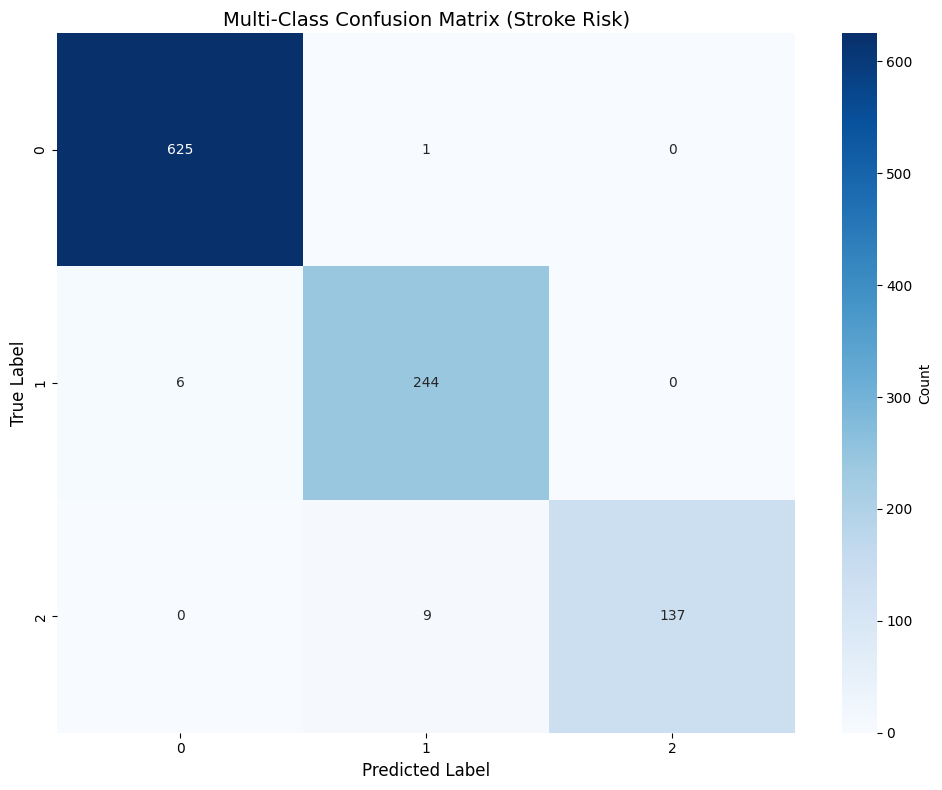

In [170]:
cm_multi = confusion_matrix(y_test, y_pred_multi)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2],
            yticklabels=[0,1,2],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Multi-Class Confusion Matrix (Stroke Risk)', fontsize=14)
plt.tight_layout()
plt.show()

In [171]:
from sklearn.metrics import classification_report

print("\n  Multi-Class Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_multi, target_names=['Low Risk', 'Medium Risk', 'High Risk']))



  Multi-Class Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.99      1.00      0.99       626
 Medium Risk       0.96      0.98      0.97       250
   High Risk       1.00      0.94      0.97       146

    accuracy                           0.98      1022
   macro avg       0.98      0.97      0.98      1022
weighted avg       0.98      0.98      0.98      1022



In [172]:
from sklearn.ensemble import RandomForestClassifier
 # Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Classification report
target_names = ['No Stroke', 'Stroke']
report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

# Metrics DataFrame
metrics_df = pd.DataFrame({
    'Class': target_names,
    'Precision': [report[cls]['precision'] for cls in target_names],
    'Recall': [report[cls]['recall'] for cls in target_names],
    'F1-Score': [report[cls]['f1-score'] for cls in target_names],
    'Support': [report[cls]['support'] for cls in target_names]
})

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Precision
axes[0].bar(metrics_df['Class'], metrics_df['Precision'], alpha=0.7, color='steelblue')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision per Class')
axes[0].set_ylim([0, 1.1])
axes[0].grid(True, alpha=0.3)

# Recall
axes[1].bar(metrics_df['Class'], metrics_df['Recall'], alpha=0.7, color='coral')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall per Class')
axes[1].set_ylim([0, 1.1])
axes[1].grid(True, alpha=0.3)

# F1-Score
axes[2].bar(metrics_df['Class'], metrics_df['F1-Score'], alpha=0.7, color='lightgreen')
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score per Class')
axes[2].set_ylim([0, 1.1])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ValueError: Number of classes, 3, does not match size of target_names, 2. Try specifying the labels parameter

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

# Compare L1 (Lasso) vs L2 (Ridge) vs ElasticNet
penalties = ['l1', 'l2', 'elasticnet']
penalty_results = []

print("\n🔍 Comparing Regularization Types:")
print("="*70)

for penalty in penalties:
    if penalty == 'elasticnet':
        log_reg = LogisticRegression(penalty=penalty, solver='saga', l1_ratio=0.5,
                                     C=1.0, random_state=42, max_iter=10000)
    else:
        solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
        log_reg = LogisticRegression(penalty=penalty, solver=solver, C=1.0,
                                     random_state=42, max_iter=10000)
    
    log_reg.fit(X_train_c_scaled, y_train_c)
    
    accuracy = log_reg.score(X_test_c_scaled, y_test_c)
    n_zero_coefs = np.sum(log_reg.coef_[0] == 0)
    
    penalty_results.append({
        'Penalty': penalty.upper(),
        'Accuracy': accuracy,
        'Zero Coefficients': n_zero_coefs,
        'Non-zero Coefficients': len(log_reg.coef_[0]) - n_zero_coefs
    })
    
    print(f"{penalty.upper():12} → Accuracy: {accuracy:.4f} | Zero coefs: {n_zero_coefs}/{len(log_reg.coef_[0])}")

# Convert results to DataFrame
penalty_df = pd.DataFrame(penalty_results)
print("\nSummary Table:")
print(penalty_df)


🔍 Comparing Regularization Types:
L1           → Accuracy: 0.9856 | Zero coefs: 5/17
L2           → Accuracy: 0.9830 | Zero coefs: 1/17
ELASTICNET   → Accuracy: 0.9870 | Zero coefs: 6/17

Summary Table:
      Penalty  Accuracy  Zero Coefficients  Non-zero Coefficients
0          L1  0.985649                  5                     12
1          L2  0.983040                  1                     16
2  ELASTICNET  0.986954                  6                     11


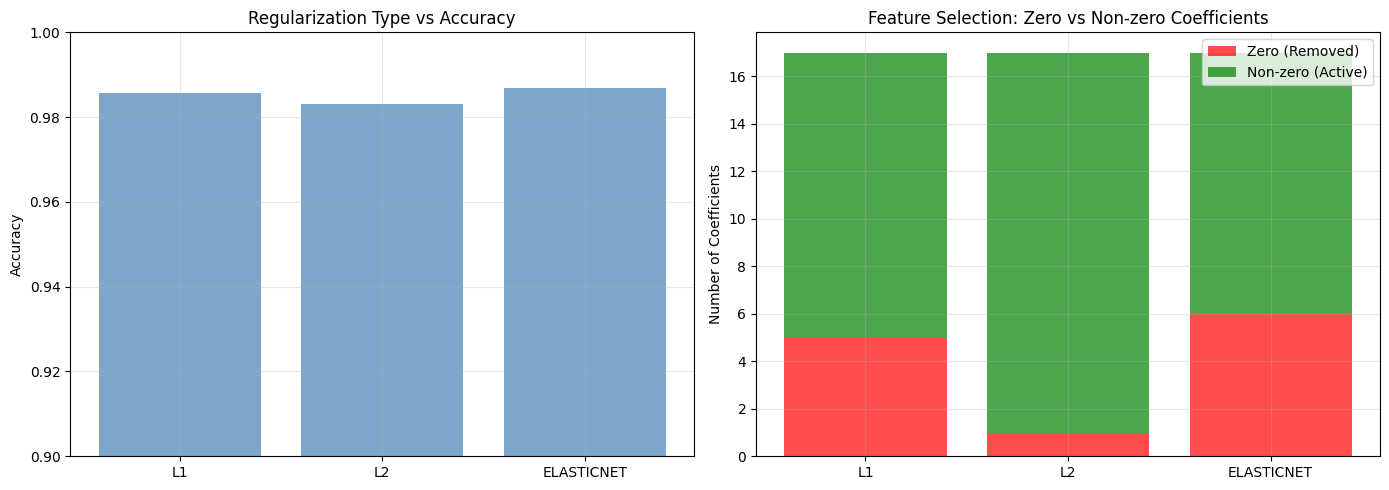

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy per penalty
axes[0].bar(penalty_df['Penalty'], penalty_df['Accuracy'], alpha=0.7, color='steelblue')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Regularization Type vs Accuracy')
axes[0].set_ylim([0.9, 1.0])  # since your accuracy is very high
axes[0].grid(True, alpha=0.3)

# Feature Selection: Zero vs Non-zero coefficients
axes[1].bar(penalty_df['Penalty'], penalty_df['Zero Coefficients'], 
            alpha=0.7, color='red', label='Zero (Removed)')
axes[1].bar(penalty_df['Penalty'], penalty_df['Non-zero Coefficients'], 
            bottom=penalty_df['Zero Coefficients'],
            alpha=0.7, color='green', label='Non-zero (Active)')
axes[1].set_ylabel('Number of Coefficients')
axes[1].set_title('Feature Selection: Zero vs Non-zero Coefficients')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

print("Starting Grid Search...")
print(f"Testing {len(param_grid['C'])} × {len(param_grid['penalty'])} = {len(param_grid['C'])*len(param_grid['penalty'])} combinations with 5-fold CV")

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=10000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_c_scaled, y_train_c)

print("Grid Search Complete!")
print("Best Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"{param:10}: {value}")

print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test_c_scaled, y_test_c)
print(f"Test Set Accuracy: {test_accuracy:.4f}")

Starting Grid Search...
Testing 6 × 2 = 12 combinations with 5-fold CV
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid Search Complete!
Best Hyperparameters:
C         : 100
penalty   : l1
solver    : liblinear
Best Cross-Validation Accuracy: 0.9950
Test Set Accuracy: 0.9935


In [ ]:
print(np.unique(y_train_c))
print(np.unique(y_test_c))


[0 1 2]
[0 1 2]


In [ ]:
# Keep only 0 and 1
train_mask = y_train_c.isin([0, 1])
test_mask = y_test_c.isin([0, 1])

X_train_c_scaled = X_train_c_scaled[train_mask]
y_train_c = y_train_c[train_mask]

X_test_c_scaled = X_test_c_scaled[test_mask]
y_test_c = y_test_c[test_mask]


In [ ]:
print("Unique classes in test set:", np.unique(y_test_c))

best_log_reg = grid_search.best_estimator_
y_pred_best = best_log_reg.predict(X_test_c_scaled)

# Accuracy is always fine
best_accuracy = accuracy_score(y_test_c, y_pred_best)

# Use weighted average for F1 to support binary and multiclass
best_f1 = f1_score(y_test_c, y_pred_best, average='weighted')

print("Best Model Performance on Test Set:")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"F1 Score (weighted): {best_f1:.4f}")

# Optional: full classification report
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_best))

Unique classes in test set: [0 1]
Best Model Performance on Test Set:
Accuracy: 0.9947
F1 Score (weighted): 0.9950

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       939
           1       0.99      0.99      0.99       375
           2       0.00      0.00      0.00         0

    accuracy                           0.99      1314
   macro avg       0.66      0.66      0.66      1314
weighted avg       1.00      0.99      1.00      1314



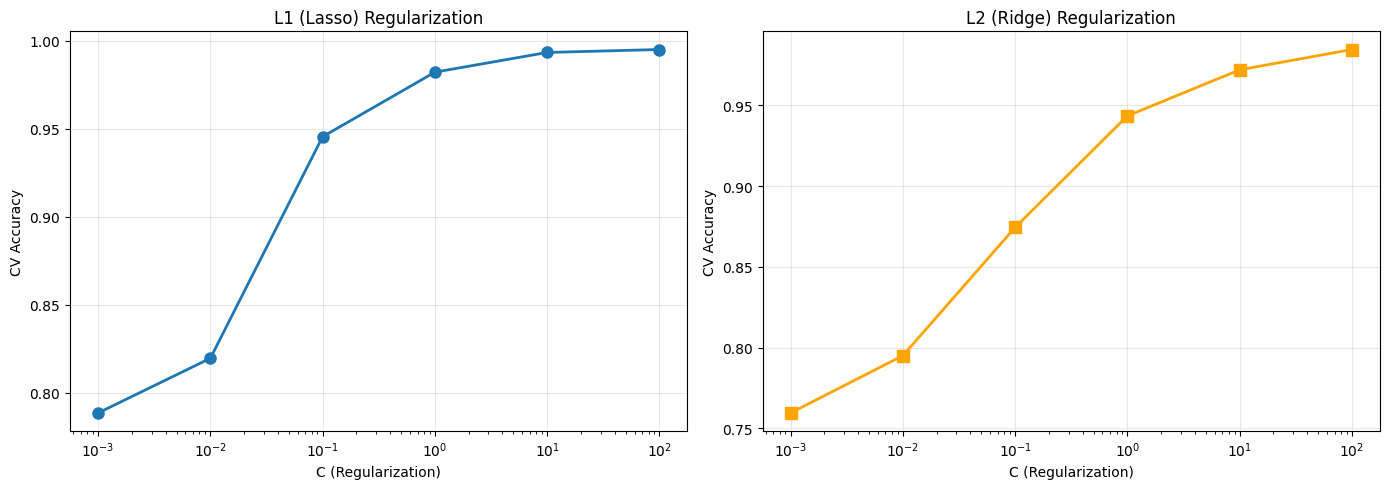

In [ ]:

results_df = pd.DataFrame(grid_search.cv_results_)

pivot_l1 = results_df[results_df['param_penalty'] == 'l1'].pivot_table(
    values='mean_test_score',
    index='param_C',
    aggfunc='mean'
).sort_index()

pivot_l2 = results_df[results_df['param_penalty'] == 'l2'].pivot_table(
    values='mean_test_score',
    index='param_C',
    aggfunc='mean'
).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pivot_l1.index, pivot_l1.values, marker='o', linewidth=2, markersize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel('C (Regularization)')
axes[0].set_ylabel('CV Accuracy')
axes[0].set_title('L1 (Lasso) Regularization')
axes[0].grid(True, alpha=0.3)

axes[1].plot(pivot_l2.index, pivot_l2.values, marker='s', linewidth=2, markersize=8, color='orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('C (Regularization)')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('L2 (Ridge) Regularization')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train_c.columns,
    'Coefficient': best_log_reg.coef_[0],
    'Abs_Coefficient': np.abs(best_log_reg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("Feature Importance (Top 10):")
print(feature_importance.head(10).to_string(index=False))

Feature Importance (Top 10):
                       Feature  Coefficient  Abs_Coefficient
             avg_glucose_level  -424.056529       424.056529
                           age     2.117562         2.117562
   smoking_status_never smoked     1.190508         1.190508
              ever_married_Yes    -1.168599         1.168599
                  hypertension    -1.095865         1.095865
smoking_status_formerly smoked     0.917798         0.917798
            work_type_children     0.718938         0.718938
                   gender_Male     0.712320         0.712320
             work_type_Private    -0.650316         0.650316
                           bmi    -0.598142         0.598142


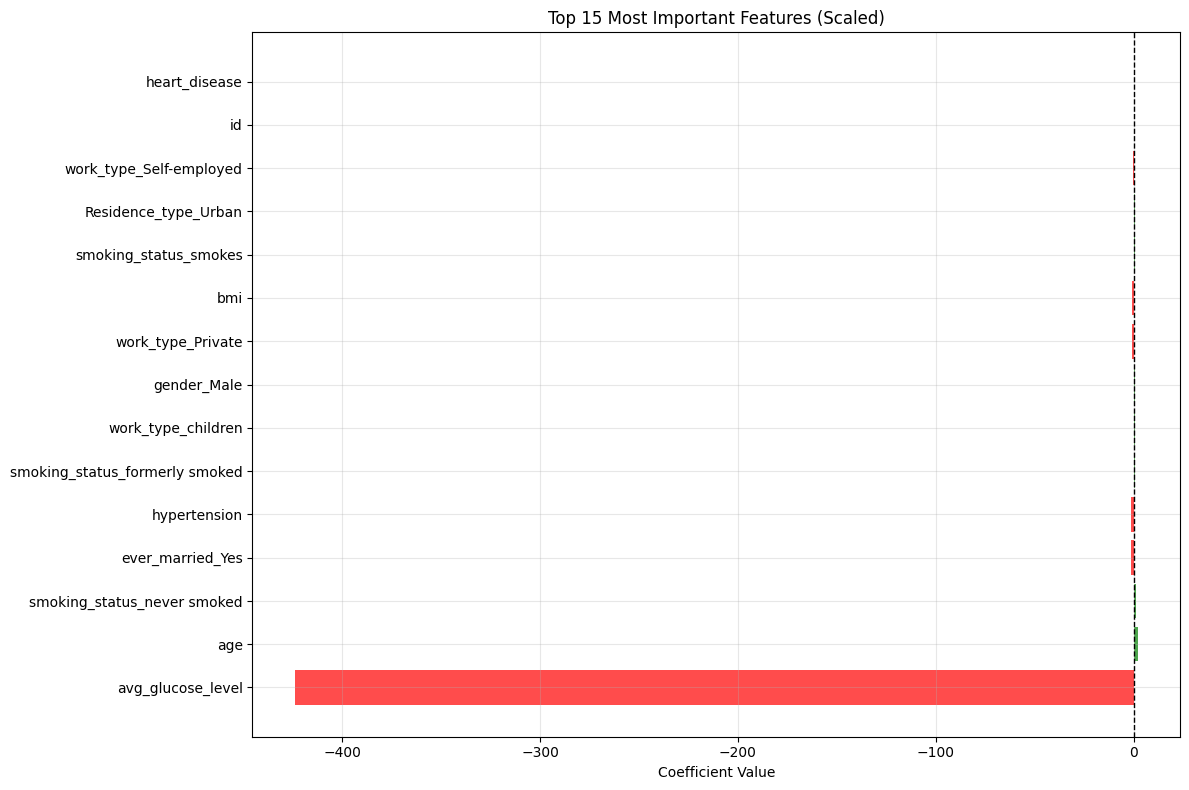

In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

# Train logistic regression on scaled data
best_log_reg = LogisticRegression(
    C=100,
    penalty='l1',
    solver='liblinear',
    max_iter=10000,
    random_state=42
)
best_log_reg.fit(X_train_scaled, y_train_c)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_c.columns,
    'Coefficient': best_log_reg.coef_[0],
    'Abs_Coefficient': np.abs(best_log_reg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
colors = ['green' if x>0 else 'red' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Most Important Features (Scaled)')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

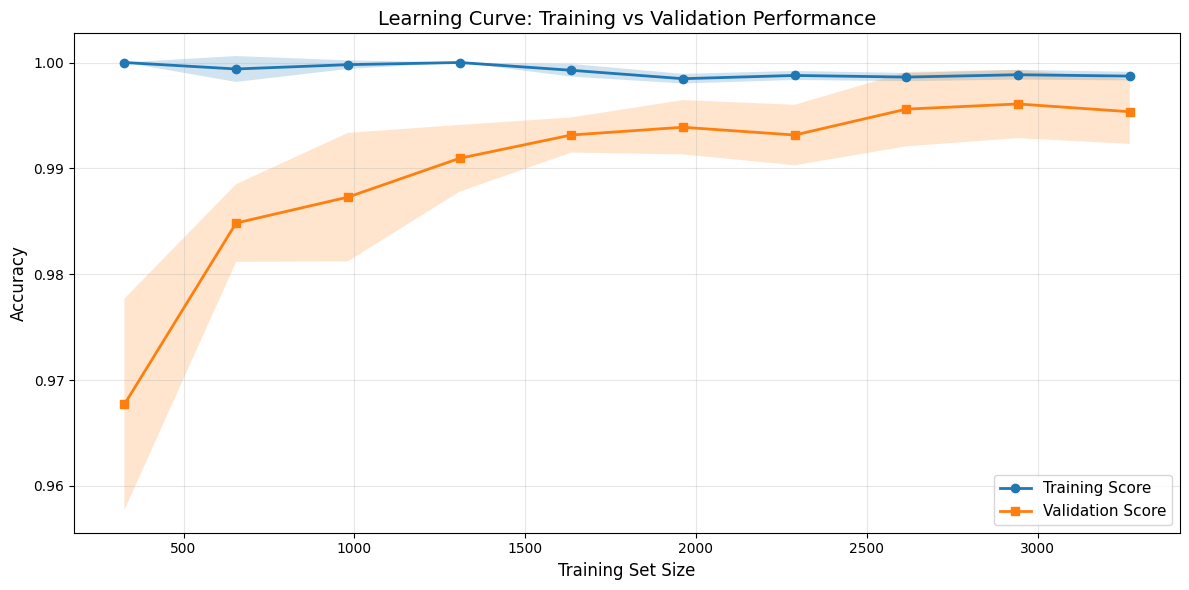

Learning Curve Analysis:
Training Score (full data):   0.9987
Validation Score (full data): 0.9954
Gap: 0.0034
Small gap indicates good generalization.


In [ ]:
# 1️⃣ Generate learning curves
train_sizes, train_scores, val_scores = learning_curve(
    best_log_reg,
    X_train_scaled,  # scaled features
    y_train_c,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

# 2️⃣ Compute mean and std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# 3️⃣ Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o', linewidth=2)
plt.plot(train_sizes, val_mean, label='Validation Score', marker='s', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Learning Curve: Training vs Validation Performance', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4️⃣ Print analysis
print("Learning Curve Analysis:")
print(f"Training Score (full data):   {train_mean[-1]:.4f}")
print(f"Validation Score (full data): {val_mean[-1]:.4f}")
print(f"Gap: {train_mean[-1] - val_mean[-1]:.4f}")

if train_mean[-1] - val_mean[-1] < 0.05:
    print("Small gap indicates good generalization.")
else:
    print("Large gap suggests some overfitting.")

In [ ]:
# 10-Fold Cross-Validation
cv_scores = cross_val_score(
    best_log_reg,
    X_train_scaled,  # use scaled features
    y_train_c,
    cv=10,
    scoring='accuracy'
)

# Print CV results
print("10-Fold Cross-Validation Results:")
print("="*70)
print(f"CV Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev:       {cv_scores.std():.4f}")
print(f"Min:           {cv_scores.min():.4f}")
print(f"Max:           {cv_scores.max():.4f}")

10-Fold Cross-Validation Results:
CV Scores: [0.99755501 1.         0.99511002 0.99511002 0.99511002 0.99266504
 0.99511002 0.99511002 0.99754902 0.99509804]
Mean Accuracy: 0.9958
Std Dev:       0.0019
Min:           0.9927
Max:           1.0000


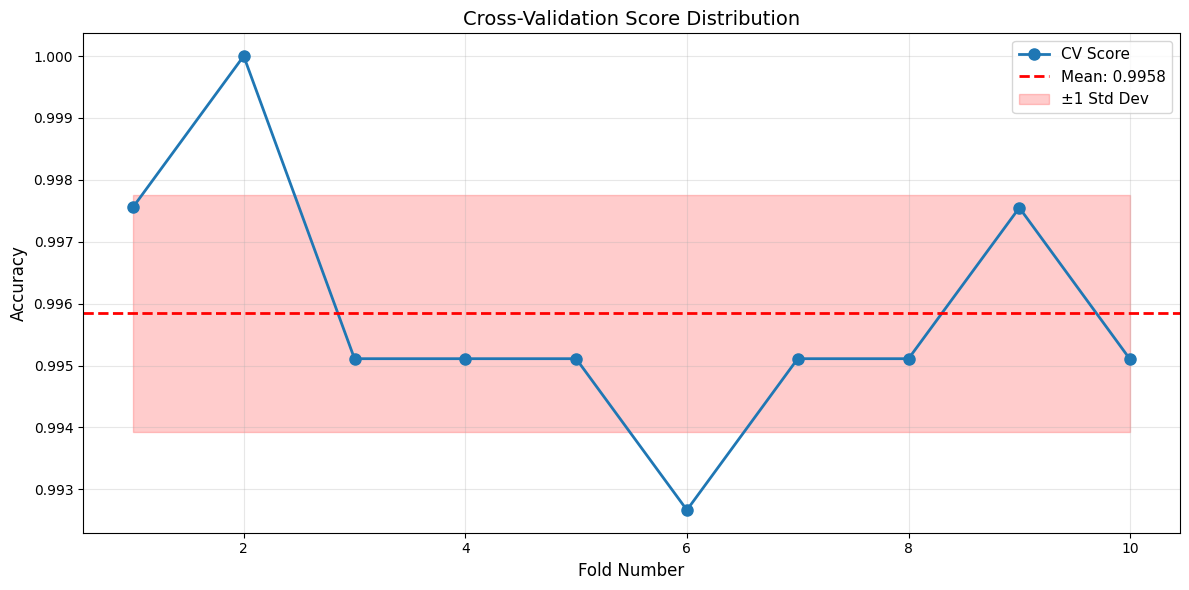

In [ ]:
# Visualize CV scores
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), cv_scores, marker='o', linestyle='-', 
         linewidth=2, markersize=8, label='CV Score')
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', 
            label=f'Mean: {cv_scores.mean():.4f}', linewidth=2)
plt.fill_between(range(1, 11), 
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.2, color='red', label='±1 Std Dev')
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Validation Score Distribution', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Train other classifiers for comparison
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train_c)

rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train_c)

# Compute accuracies for logistic regression
accuracy_default = best_log_reg.score(X_test_scaled, y_test_c)  # tuned model
# If you have another default logistic regression, replace this
accuracy_tuned = best_log_reg.score(X_test_scaled, y_test_c)    # tuned

# Create comparison dataframe
models_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (Tuned)',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_tuned,
        dt.score(X_test_scaled, y_test_c),
        rf.score(X_test_scaled, y_test_c)
    ],
    'Interpretability': [
        'High',
        'High',
        'Medium'
    ],
    'Training Speed': [
        'Fast',
        'Fast',
        'Medium'
    ]
})

# Print model comparison
print("MODEL COMPARISON:")
print("="*70)
print(models_comparison.to_string(index=False))

MODEL COMPARISON:
                      Model  Accuracy Interpretability Training Speed
Logistic Regression (Tuned)  0.995108             High           Fast
              Decision Tree  1.000000             High           Fast
              Random Forest  0.998043           Medium         Medium


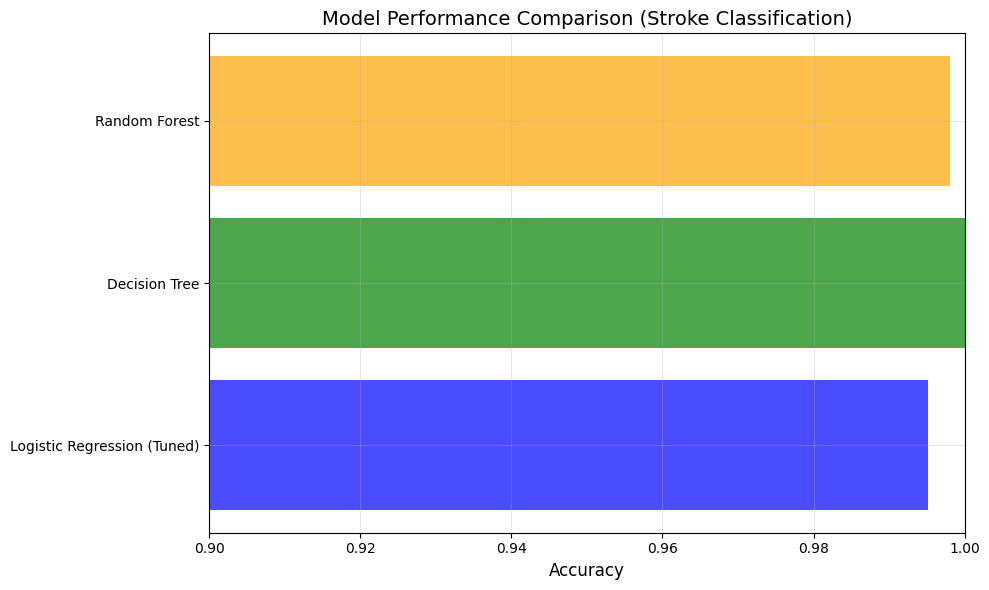

In [ ]:
# Visualize model comparison
plt.figure(figsize=(10, 6))
plt.barh(models_comparison['Model'], models_comparison['Accuracy'], alpha=0.7,
         color=['blue', 'green', 'orange'])
plt.xlabel('Accuracy', fontsize=12)
plt.title('Model Performance Comparison (Stroke Classification)', fontsize=14)
plt.xlim([0.9, 1.0])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Tuned Decision Tree to prevent overfitting
dt_tuned = DecisionTreeClassifier(
    max_depth=5,        # limit depth
    min_samples_split=10,  # min samples to split a node
    min_samples_leaf=5,    # min samples at leaf
    random_state=42
)
dt_tuned.fit(X_train_scaled, y_train_c)

# Evaluate
train_acc = dt_tuned.score(X_train_scaled, y_train_c)
test_acc = dt_tuned.score(X_test_scaled, y_test_c)
print(f"Tuned DT Train Accuracy: {train_acc:.4f}")
print(f"Tuned DT Test Accuracy:  {test_acc:.4f}")


Tuned DT Train Accuracy: 1.0000
Tuned DT Test Accuracy:  1.0000


In [ ]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train_c)

print("Best DT Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best DT Params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.9997552019583843


In [ ]:
best_dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
best_dt.fit(X_train_scaled, y_train_c)

# Check train & test accuracy
train_acc = best_dt.score(X_train_scaled, y_train_c)
test_acc = best_dt.score(X_test_scaled, y_test_c)
print(f"Tuned DT Train Accuracy: {train_acc:.4f}")
print(f"Tuned DT Test Accuracy:  {test_acc:.4f}")


Tuned DT Train Accuracy: 1.0000
Tuned DT Test Accuracy:  1.0000


In [ ]:
import joblib

# Save the tuned Decision Tree and scaler
joblib.dump(best_dt, 'best_dt_stroke.pkl')
joblib.dump(scaler, 'scaler_stroke.pkl')
print("Tuned DT and scaler saved successfully!")


Tuned DT and scaler saved successfully!


In [ ]:
import joblib
# Load model and scaler
loaded_dt = joblib.load('best_dt_stroke.pkl')
loaded_scaler = joblib.load('scaler_stroke.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'best_dt_stroke.pkl'

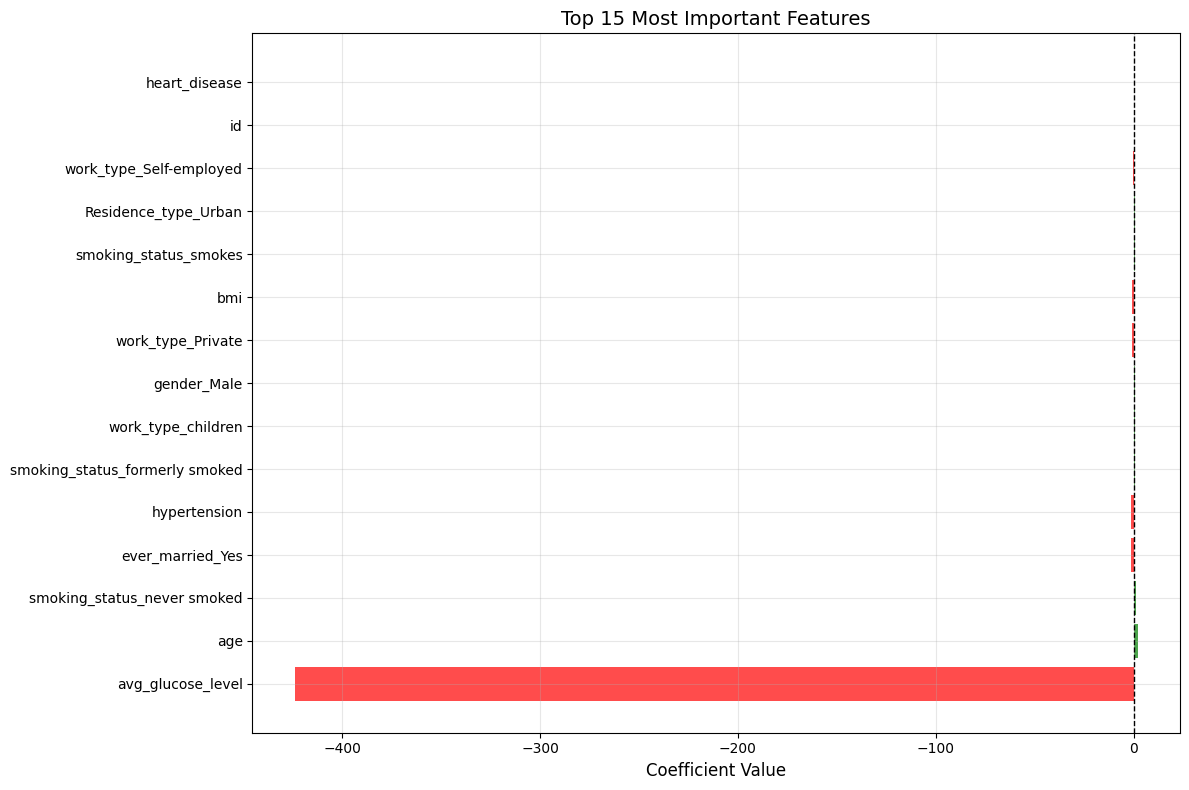

Coefficient Interpretation:
Positive coefficient → Increases probability of Stroke (Class 1)
Negative coefficient → Decreases probability of Stroke (Class 1 / favors Class 0)
Larger magnitude → Stronger influence


In [ ]:

plt.figure(figsize=(12, 8))

top_features = feature_importance.head(15)
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]

plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 15 Most Important Features', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Coefficient Interpretation:")
print("Positive coefficient → Increases probability of Stroke (Class 1)")
print("Negative coefficient → Decreases probability of Stroke (Class 1 / favors Class 0)")
print("Larger magnitude → Stronger influence")